# Lab 02: Where Is the Star, and How Sure Are You Allowed to Be?

**ASTR 457, Fall 2026, posted Thu Sep 10, due Wed Sep 16 by Noon (fork → PR, as always)**

*Why this lab: centroiding is how every position in every catalog you'll ever use was measured, and the Cramér–Rao bound is the professional's sanity check (the best precision any measurement can claim) that tells you instantly when an error bar in a paper (or from an AI) is too good to be true.*

Every one of you has your own dataset: `data/<your netid>.csv`, with a single column `x`,
the arrival positions, in pixels, of individual photons on a 1-D detector window spanning
$[0, 64]$ px. Most of the photons come from a star whose image on the detector is a Moffat
profile centered at $x_0$, with shape parameters $\beta = 2.5$ and $r_0 = 4$ px (both known
to you). The rest are **background**: a fraction $f_{\rm bg}$ of the photons, spread uniformly
across the window. I know the true $x_0$ and $f_{\rm bg}$ for your dataset. You don't, and you
can't look them up, and your classmates' values are different from yours. (So are their photon
counts, so your Part 2 bound is yours alone.)

**How this is graded.** Not on whether your code runs, but on whether your answers are *right*
and your uncertainties are *honest*. Part of your grade comes from how close your reported
$x_0$ and $f_{\rm bg}$ are to your truth **in units of your own reported uncertainty**. Report
tiny error bars you can't back up and you will lose points even if your central value is close.
Report huge error bars to be safe and you'll lose points too. Calibration is the skill.
And this week there is a floor under "huge": your reported $\sigma_{x_0}$ may not exceed
**3× the Cramér–Rao bound** you compute in Part 2. An error bar bigger than that is not
caution, since it's an estimator you should have discarded.

**AI policy reminder.** Use whatever tools you like, including AI assistants, and document
it in Part 4. You may be selected to defend this lab in person. Welcome to doing research.

# Notes
**Moffat profile**- based upon the Cauchy distribution, can accurately recover point spread functions that can't be modeled by a Gaussian

**Cauchy distribution**- Heavy tails, formally undefined mean or vairance

$f(x: x_0, \gamma)$ -> x_0: median / mode, $\gamma$: mean absolute deviation




## Part 1: The naive estimator (15%)

Load your photon list and plot a histogram of the arrival positions (choose your binning
deliberately, and you'll defend it). Then estimate the star's position the obvious way: the
**sample mean** of all the photon positions, with uncertainty $s/\sqrt{N}$ (the standard
error of the mean). Report $\hat{x}_0 \pm \sigma$.

Then answer, in a few sentences: is this estimator biased for *your* dataset, and why?
Which way does the bias pull, and what controls its size? (This estimator is *supposed* to
be biased. Understanding exactly how (and what the background has to do with it) is the
point.)

In [135]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from scipy.special import gamma
from numpy.random import standard_t
np.random.seed(123)

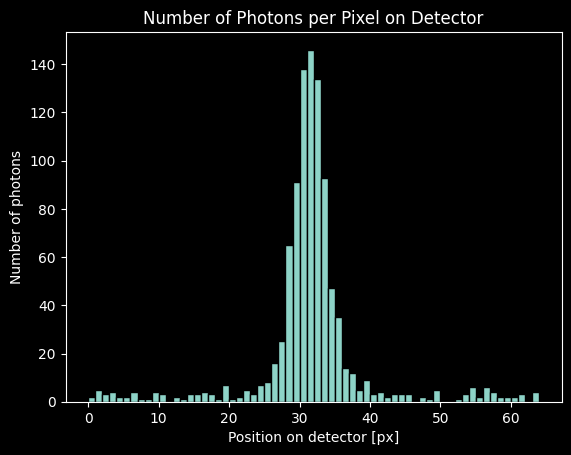

Photon location sample mean: 31.546+/-0.255 px
Expected value of photon location: 31.548 px
Bias: -0.002 px


In [136]:
# Part 1: your work here

netid = 'asteves2'
data = pd.read_csv(f'/Users/andrewsteves/ast457_2026_Fall/labs/02/data/{netid}.csv')
x = data['x'].values

mu = np.sum(x) / len(x)
s = np.sqrt(np.sum((x - mu)**2) / len(x) - 1) / np.sqrt(len(x))

bins = np.arange(0, 65, 1)  # 64 bins of width 1px so that each bin corresponds to a pixel

fig = plt.figure()
counts, bins, bars = plt.hist(data['x'], bins = bins, edgecolor = 'black')

plt.xlabel('Position on detector [px]')
plt.ylabel('Number of photons')
plt.title('Number of Photons per Pixel on Detector')

plt.show()

midpoints = (bins[:-1] + bins[1:]) / 2
e_v = np.sum(counts * midpoints) / np.sum(counts)

print(f'Photon location sample mean: {mu:.3f}+/-{s:.3f} px')
print(f'Expected value of photon location: {e_v:.3f} px')
print(f'Bias: {mu - e_v:.3f} px')    # expected value > sample mean

**ANSWER (a few sentences):**

Because the sample mean of the dataset is not equal to the expected value of the photon location, the estimator is biased. In this case, the bias is negative meaning the estimator underestimates the position of the star to be -0.002 pixels to the left of where it is expected to be. The background radiation is likely responsible fot his bias by introducing random signal fluctuations to the detector that skew the sample mean of the photon locations.

## Part 2: Estimators you can defend (40%)

Now do it properly. Estimate $x_0$ **three more ways** and compare:

1. **The median** of the photon positions. Robust, simple, but is it unbiased here, and
   what is its variance? (You may answer the variance question empirically in Part 3.)
2. **A sigma-clipped mean**: iteratively remove photons far from the current estimate,
   re-estimate, repeat until it converges. Be explicit about your clipping threshold and
   why you chose it.
3. **Maximum likelihood on the mixture model.** Each photon is background with probability
   $f_{\rm bg}$, or from the star otherwise, so the probability density for a single photon at
   position $x$ is

   $$p(x \mid x_0, f_{\rm bg}) \;=\; \frac{f_{\rm bg}}{64} \;+\; (1 - f_{\rm bg})\,
   \frac{\Gamma(\beta)}{r_0\sqrt{\pi}\,\Gamma(\beta - \tfrac{1}{2})}
   \left[1 + \left(\frac{x - x_0}{r_0}\right)^2\right]^{-\beta}$$

   with $\beta = 2.5$ and $r_0 = 4$ px. Maximize $\sum_i \ln p(x_i \mid x_0, f_{\rm bg})$ over
   both parameters (see Ivezić, Connolly, VanderPlas & Gray, §4.2, for the machinery; this
   is the same likelihood game with different symbols). Get uncertainties from the curvature
   of the log-likelihood at its peak (the observed information), and say so.

Then compute the **Cramér–Rao bound**: the smallest variance any unbiased estimator of $x_0$
can achieve given your $N$ photons. The per-photon Fisher information
$I(x_0) = \int \frac{1}{p}\left(\frac{\partial p}{\partial x_0}\right)^2 dx$ is yours to
evaluate (numerically over the window is fine) and the bound is
$\sigma_{x_0} \geq 1/\sqrt{N\,I}$. Treat both parameters as unknown: the honest bound comes
from inverting the $2\times 2$ Fisher matrix, not the $x_0$ term alone. How close does each
of your four estimators get?

(Two technicalities you may use without proof: photons landing outside the window were lost,
but for your $x_0$ the lost fraction is negligible, and checking that claim makes a fine
Part 3 sensitivity test. And for simulating: a 1-D Moffat with exponent $\beta$ is a
Student-$t$ distribution with $\nu = 2\beta - 1$ degrees of freedom, scaled by
$r_0/\sqrt{\nu}$.)

Commit to a **final answer**, one $x_0 \pm \sigma$ and $f_{\rm bg} \pm \sigma$ you'd put in
a paper, and justify the choice. State clearly how you estimated your uncertainties and why
you believe them. Remember the 3× rule from the header.

In [137]:
# Part 2: your work here
n_boot = 2000
r0 = 4
beta = 2.5

# Median
samp_meds = []
for i in range(n_boot):                                 #Generating 10000 random samples
    rng = np.random.default_rng(i)                      #Ensuring that all seeds generate different random numbers
    samp = rng.choice(x, size = 50, replace = True)     #Randomly sampling roughly 2% of entire data set with each pass
    med = np.median(samp)
    samp_meds.append(med)

med = np.mean(samp_meds)
var_med = np.var(samp_meds)
stddev_med = np.std(samp_meds)

# Sigma Clipping
max_iter = 10
k = 3    #All points within 3 standard deviations (~99% of data if Gaussian) are kept
mu = np.mean(x)
stddev = np.std(x)
x_c = x.copy()

for i in range(max_iter):
    unclipped = []
    clipped = []
    for j in range(len(x_c)):
        if np.abs(x_c[j]-mu) < k * stddev:
            unclipped.append(x_c[j])
        else:
            clipped.append(x_c[j])

    if len(clipped) == 0:
        break

    x_c = np.array(unclipped)
    mu = np.mean(x_c)
    stddev = np.std(x_c)

unclipped_data = unclipped.copy()
sig_x0 = np.mean(unclipped_data)
sig_x0_stddev = np.std(unclipped_data)
sig_x0_var = np.var(unclipped_data)

# Maximum Likelihood Mixture Model
def neg_log_likelihood(theta, x_data, r, b):
    '''
    param x_data (list): observed photon positions on detector
    param theta (tuple): initial guesses for background fraction and mean
    return:
    '''

    x0, f = theta[0], theta[1]
    normalization = r * np.sqrt(np.pi) * gamma(b - 1/2)
    prof = (1 + ((x_data - x0) / r)**2)**(-b)
    fun = -np.log(f / 64 + (1 - f) * gamma(b) / normalization * prof)
    return np.sum(fun)

theta = [31.5, 0.02]                                                    #Initial guesses for mean and background probability, rough estimate of mean by previous calculations and value for bias calculated in part 1
outputs = minimize(neg_log_likelihood, x0 = theta, args = (x, r0, beta))
llh_x0, f = outputs.x[0], outputs.x[1]
cov = outputs.hess_inv                                                  #Hessian matrix stores curvature of each second partial derivative
llh_x0_stddev, f_stddev = np.sqrt(cov[0, 0]), np.sqrt(cov[1, 1])

x_grid = np.linspace(0, 64, 1000)
a = (1 - f) * gamma(beta) / (r0 * np.sqrt(np.pi) * gamma(beta - 1/2))
p = f / 64 + a * (1 + ((x_grid - llh_x0) / r0)**2)**(-beta)
dp_dx0 = a * (-2 * beta / r0 * (1 + ((x_grid - llh_x0) / r0)**2)**(-beta - 1) * (x_grid - llh_x0) / r0)

dx = x_grid[1] - x_grid[0]
I = np.sum(1 / p * dp_dx0**2) * dx
lim = 1 / np.sqrt(len(x) * I)


print(f'Randomly sampled median: {med:.3f}+/-{stddev_med:.3f} px, Variance: {var_med:.3f} px^2')
print(f'Sigma Clipped Mean: {sig_x0:.3f}+/-{sig_x0_stddev:.3f} px, Variance: {sig_x0_var:.3f} px^2')
print(f'Likelihood Mean: {llh_x0:.3f}+/-{llh_x0_stddev:.3f} px, Variance: {llh_x0_stddev**2:.3f} px^2')
print(f'Background Fraction: {f:.3f}+/-{f_stddev:.3f} px')
print(f'C-R Bound: 3sigma >= {lim:.3f}')

Randomly sampled median: 31.488+/-0.459 px, Variance: 0.211 px^2
Sigma Clipped Mean: 31.477+/-2.427 px, Variance: 5.891 px^2
Likelihood Mean: 31.475+/-0.086 px, Variance: 0.007 px^2
Background Fraction: 0.160+/-0.015 px
C-R Bound: 3sigma >= 0.086


f**FINAL ANSWER:** $x_0 = $ 31.475 $\pm$ 0.086 px , $f_{\rm bg} = $ 0.160 $\pm$ 0.015 , Cramér–Rao bound $\sigma_{x_0}^{\rm CRB} = $ 0.086 px

**Justification and uncertainty method (a short paragraph):**

The mixture model seems to produce the best results because it has the smallest variance (and standard deviation). Here, the variance was calculated in the minimize function where the inverse Hessian contains the second partial derivatives of the distribution. The likelihood model (and also the randomly sampled median) has a variance less then the upper limit allowed by the Cramer-Rao bound, so we can be sure that the observed data can provide information about the parameters $x_0$ and $f_{bg}$

## Part 3: The verification plan, written first and then executed (35%)

This is the headline of this lab. **Before you run anything below, write the plan** (3a).
A verification plan you invent after seeing the results is a rationalization.

**3a. The plan.** List the checks you will run to decide whether to trust your Part 2
numbers. At minimum, address:

1. **Closure**: simulate a dataset with a truth *you* choose (the Student-$t$ fact from
   Part 2 makes this easy) and confirm your estimator recovers it.
2. **Bias and efficiency**: Monte Carlo all four estimators on many simulated datasets at
   plausible parameters. Plot their bias and their variance against the Cramér–Rao bound.
   This is *the* figure of this lab.
3. **Coverage**: across your simulations, do your 68% intervals contain the truth 68% of
   the time?
4. **Sensitivity**: what happens to your $\hat{x}_0$ if $\beta$ or $r_0$ are slightly wrong,
   or if the lost-photon fraction isn't negligible after all?

For **each** check, state *in advance* what failure would look like. A check that cannot
fail is not a check.

**3b. The execution.** Run the plan. Report what each check found, including anything that
failed or surprised you. A failed check honestly reported and diagnosed is worth more than
a wall of green checkmarks.

**VERIFICATION PLAN (write this before running 3b):**

The verification for the likelihood estimator found in part 2 will start with creating a synthetic dataset with a chosen mean, using the same r0 and beta parameters as given above and using the fact that f_bg = 0. Because I know the x0 value, I will be able to verify whether the method used previously returned an accurate value for the x0 position. The bias can be calculated by iterating over the calculation of the true x0, and taking the difference between the calculated and true values. The efficiency can be found by calculating spread (variance) of a number of repeated simulations. Plotting the bias and efficiency can be plotted together with the CR-bound as a line, where estimators near the CR-bound and close to zero bias are preferred. To assess coverage, I can compare the number of iterations where the true mean lies within one standard deviation of the estimated mean to the ones where the true mean is not contained within one standard deviation. To test sensitivity, I will define a small range of numbers for $\hat{x}_0$, $\beta$, and $r_0$ and rerun these test to better understand how small deviations to the parameters affect the estimates by calculated the variance of x0 values over the range of parameters.

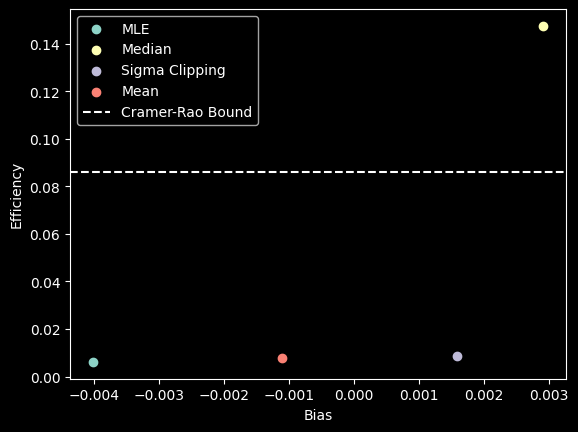

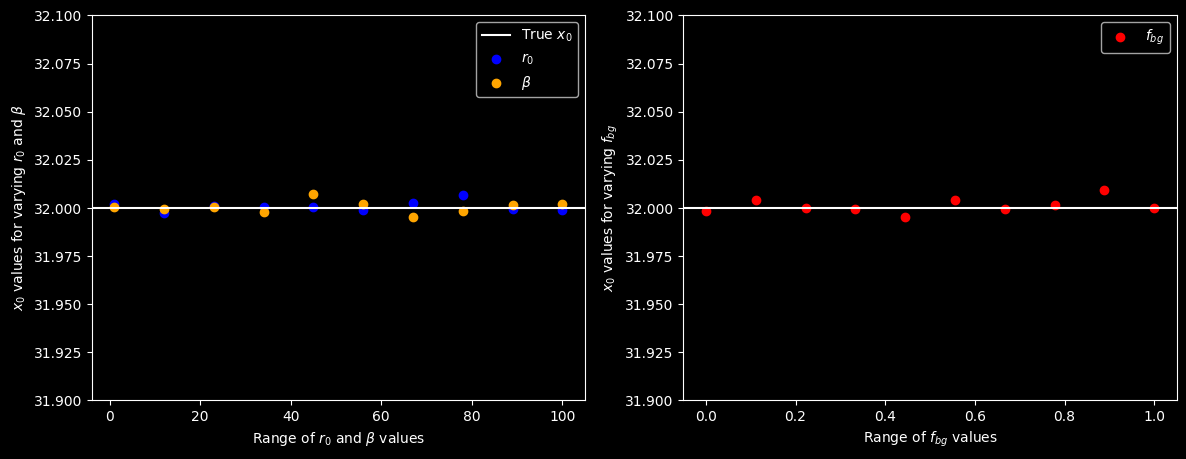

Maximum Likelihood Estimation:
Simulated x0 MLE: 31.996+/-0.078 px
MLE Coverage: 66.200%
----------------------------------------------------
Arithmetic Mean:
Simulated x0 Mean: 31.999+/-0.089 px
Mean Coverage: 100.000%
----------------------------------------------------
Median
Simulated x0 Median: 32.003+/-0.384 px
MLE Coverage: 99.800%
----------------------------------------------------
Sigma-Clipping
Simulated x0 Sigma Clipping: 32.002+/-0.093 px
MLE Coverage: 68.700%


In [172]:
# Part 3b: execute the plan here

#Generate a Student t with mu = 32 (chosen value)
x0_chosen = 32
N = len(x)              #Generating a synthetic dataset with the same number of points as the original
n_sims = 1000           #Iterating over 1000 randomly generated student t samples of the same length as the original data set

#Estimator: maximum likelihood estimation
def nnl(theta, x_data, r, b):
    #Function is the same as the previous negative log likelihood, using f_bg = 0
    x0 = theta
    normalization = r * np.sqrt(np.pi) * gamma(b - 1/2)
    prof = (1 + ((x_data - x0) / r)**2)**(-b)
    fun = -np.log(gamma(b) / normalization * prof)
    return np.sum(fun)

x0_mle = []
stddev_mle = []
covrg_mle = []

for i in range(n_sims):
    nu = 2 * beta - 1
    T = standard_t(nu, size = N)
    x = x0_chosen + r0 / np.sqrt(nu) * T

    theta = x0_chosen
    outputs = minimize(nnl, x0 = theta, args = (x, r0, beta))
    mle_x0_sim = outputs.x[0]
    cov = outputs.hess_inv
    mle_x0_stddev_sim = np.sqrt(cov[0, 0])
    x0_mle.append(mle_x0_sim)
    stddev_mle.append(mle_x0_stddev_sim)

    if np.abs(mle_x0_sim - x0_chosen) <= mle_x0_stddev_sim:
        covrg_mle.append(True)

coverage_ratio_mle = len(covrg_mle) / n_sims * 100


bias_mle = np.mean(x0_mle) - x0_chosen
eff_mle = np.var(x0_mle)

x0_rec = np.mean(x0_mle)
stddev_rec = np.std(x0_mle)

#Estimator: arithmetic mean
x0_mean = []
stddev_mean = []
covrg_mean = []

for i in range(n_sims):
    nu = 2 * beta - 1
    T = standard_t(nu, size = N)
    x = x0_chosen + r0 / np.sqrt(nu) * T

    x0_m = np.mean(x)
    x0_mean.append(np.mean(x))
    stddev_mean.append(np.std(x))

    if np.abs(x0_m - x0_chosen) <= np.std(x):
        covrg_mean.append(True)

coverage_ratio_mean = len(covrg_mean) / n_sims * 100

x0_mean_rec = np.mean(x0_mean)
stddev_mean_rec = np.std(x0_mean)
bias_mean = x0_mean_rec - x0_chosen
eff_mean = np.var(x0_mean)

#Estimator: median
x0_med = []
stddev_med = []
covrg_med = []

for i in range(n_sims):
    nu = 2 * beta - 1
    T = standard_t(nu, size = N)
    x = x0_chosen + r0 / np.sqrt(nu) * T

    rng = np.random.default_rng(i)
    samp = rng.choice(x, size = 50, replace = True)

    x0_med.append(np.median(samp))
    stddev_med.append(np.std(samp))

    if np.abs(np.mean(x0_med) - x0_chosen) <= np.std(x0_med):
        covrg_med.append(True)

coverage_ratio_med = len(covrg_med) / n_sims * 100


x0_med_rec = np.mean(x0_med)
stddev_med_rec = np.std(x0_med)
bias_med = x0_med_rec - x0_chosen
eff_med = np.var(x0_med)

#Estimator: sigma clipping
x0_sig = []
stddev_sig = []
covrg_sig = []

for r in range(n_sims):
    nu = 2 * beta - 1
    T = standard_t(nu, size = N)
    x = x0_chosen + r0 / np.sqrt(nu) * T
    mu = np.mean(x)
    stddev = np.std(x)
    for i in range(max_iter):
        unclipped = []
        clipped = []
        for j in range(len(x)):
            if np.abs(x[j]-mu) < k * stddev:
                unclipped.append(x[j])
            else:
                clipped.append(x[j])

        if len(clipped) == 0:
            break
        mu = np.mean(unclipped)
        stddev = np.std(unclipped)


    x_c = np.array(unclipped)
    x0_sig.append(np.mean(x))
    stddev_sig.append(np.std(x))

    if np.abs(np.mean(x) - x0_chosen) <= np.std(x0_sig):
        covrg_sig.append(True)

coverage_ratio_sig = len(covrg_sig) / n_sims * 100

x0_sig_rec = np.mean(x0_sig)
stddev_sig_rec = np.std(x0_sig)
bias_sig = x0_sig_rec - x0_chosen
eff_sig = np.var(x0_sig)

r_vals = np.linspace(1, 100, 10)        #Radius of PSF (I believe)
b_vals = np.linspace(1, 100, 10)        #DOF of Student-t distribution
f_vals = np.linspace(0, 1, 10)          #Background fraction

def nnl_r(theta, x_data, r, b):
    #Function is the same as the previous negative log likelihood, using f_bg = 0
    x0 = theta
    normalization = r * np.sqrt(np.pi) * gamma(b - 1/2)
    prof = (1 + ((x_data - x0) / r)**2)**(-b)
    fun = -np.log(gamma(b) / normalization * prof)
    return np.sum(fun)

x0_r = []
stddev_r = []

for j in range(len(r_vals)):
    r = r_vals[j]

    x0_mle = []
    stddev_mle = []

    for i in range(n_sims):
        nu = 2 * beta - 1
        T = standard_t(nu, size = N)
        x = x0_chosen + r0 / np.sqrt(nu) * T

        theta = x0_chosen
        outputs = minimize(nnl_r, x0 = theta, args = (x, r, beta))
        mle_x0_sim = outputs.x[0]
        cov = outputs.hess_inv
        mle_x0_stddev_sim = np.sqrt(cov[0, 0])
        x0_mle.append(mle_x0_sim)
        stddev_mle.append(mle_x0_stddev_sim)

    x0_r.append(np.mean(x0_mle))
    stddev_r.append(np.std(x0_mle))

def nnl_b(theta, x_data, r, b):
    x0 = theta
    normalization = r * np.sqrt(np.pi) * gamma(b - 1/2)
    prof = (1 + ((x_data - x0) / r)**2)**(-b)
    fun = -np.log(gamma(b) / normalization * prof)
    return np.sum(fun)

x0_b = []
stddev_b = []

for j in range(len(b_vals)):
    b = b_vals[j]

    x0_mle = []
    stddev_mle = []

    for i in range(n_sims):
        nu = 2 * beta - 1
        T = standard_t(nu, size = N)
        x = x0_chosen + r0 / np.sqrt(nu) * T

        theta = x0_chosen
        outputs = minimize(nnl_b, x0 = theta, args = (x, r, beta))
        mle_x0_sim = outputs.x[0]
        cov = outputs.hess_inv
        mle_x0_stddev_sim = np.sqrt(cov[0, 0])
        x0_mle.append(mle_x0_sim)
        stddev_mle.append(mle_x0_stddev_sim)

    x0_b.append(np.mean(x0_mle))
    stddev_b.append(np.std(x0_mle))

def nnl_f(theta, x_data, r, b, f):
    x0 = theta
    normalization = r * np.sqrt(np.pi) * gamma(b - 1/2)
    prof = (1 + ((x_data - x0) / r)**2)**(-b)
    fun = -np.log(gamma(b) / normalization * prof)
    return np.sum(fun)

x0_f = []
stddev_f = []

for j in range(len(f_vals)):
    f = f_vals[j]

    x0_mle = []
    stddev_mle = []

    for i in range(n_sims):
        nu = 2 * beta - 1
        T = standard_t(nu, size = N)
        x = x0_chosen + r0 / np.sqrt(nu) * T

        n_keep = int((1 - f) * len(x))
        idx = np.random.choice(len(x), size = n_keep, replace = False)
        x_obs = x[idx]

        theta = x0_chosen
        outputs = minimize(nnl_f, x0 = theta, args = (x_obs, r, beta, f))
        mle_x0_sim = outputs.x[0]
        cov = outputs.hess_inv
        mle_x0_stddev_sim = np.sqrt(cov[0, 0])
        x0_mle.append(mle_x0_sim)
        stddev_mle.append(mle_x0_stddev_sim)

    x0_f.append(np.mean(x0_mle))
    stddev_f.append(np.std(x0_mle))

# Bias VS. Efficiency plot
fig = plt.figure()
plt.scatter(bias_mle, eff_mle, label = 'MLE')
plt.scatter(bias_med, eff_med, label = 'Median')
plt.scatter(bias_sig, eff_sig, label = 'Sigma Clipping')
plt.scatter(bias_mean, eff_mean, label = 'Mean')
plt.axhline(lim, linestyle = '--', color = 'w', label = 'Cramer-Rao Bound')

plt.xlabel('Bias')
plt.ylabel('Efficiency')

plt.legend()
plt.show()

bias_r = np.array(x0_r) - x0_chosen
bias_b = np.array(x0_b) - x0_chosen
bias_f = np.array(x0_f) - x0_chosen

# Sensitivity Plot, looking at variance of value ranges for each nuisance parameter
figure, ax = plt.subplots(nrows = 1, ncols = 2, figsize = (14, 5))
ax[0].axhline(x0_chosen, label = r'True $x_0$')
ax[0].scatter(r_vals, x0_r, color = 'blue', label = r'$r_0$')
ax[0].scatter(b_vals, x0_b, color = 'orange', label = r'$\beta$')

ax[0].set_ylim(31.9, 32.1)
ax[0].set_xlabel(r'Range of $r_0$ and $\beta$ values')
ax[0].set_ylabel(r'$x_0$ values for varying $r_0$ and $\beta$')

ax[1].scatter(f_vals, x0_f, color = 'red', label = r"$f_{bg}$")
ax[1].axhline(x0_chosen)

ax[1].set_ylim(31.9, 32.1)
ax[1].set_xlabel(r'Range of $f_{bg}$ values')
ax[1].set_ylabel(r'$x_0$ values for varying $f_{bg}$')

ax[0].legend()
ax[1].legend()
plt.show()

print('Maximum Likelihood Estimation:')
print(f'Simulated x0 MLE: {x0_rec:.3f}+/-{stddev_rec:.3f} px')
print(f'MLE Coverage: {coverage_ratio_mle:.3f}%')
print('----------------------------------------------------')
print('Arithmetic Mean:')
print(f'Simulated x0 Mean: {x0_mean_rec:.3f}+/-{stddev_mean_rec:.3f} px')
print(f'Mean Coverage: {coverage_ratio_mean:.3f}%')
print('----------------------------------------------------')
print('Median')
print(f'Simulated x0 Median: {x0_med_rec:.3f}+/-{stddev_med_rec:.3f} px')
print(f'MLE Coverage: {coverage_ratio_med:.3f}%')
print('----------------------------------------------------')
print('Sigma-Clipping')
print(f'Simulated x0 Sigma Clipping: {x0_sig_rec:.3f}+/-{stddev_sig_rec:.3f} px')
print(f'MLE Coverage: {coverage_ratio_sig:.3f}%')



**WHAT THE CHECKS FOUND:**

It seems that the maximum likelihood estimation can likely be considered closed because it returns a most likely position that is within 1% of the chosen value and one standard deviation of the mean. From the plot, three of the four estimators fall within the Cramer-Rao bound, so they will provide information about the true parameters. The mean, median, and sigma clipping see that the true position lies within one standard deviation of the estimated position. The maximum likelihood estimator however says that the true position will be within one standard deviation of the estimated mean about 67% of the time. This may be significant enough such that the errors of the mean position estimates from that model can't be trusted. The coverage of the arithmetic mean worries me because it seems very unlikely that I can trust the uncertainty with 100% confidence, but I can't seem to find any errors in the calculation of that statistic. The same issue applies to the median. At 1000 simulations there is still some fluctuation of the coverage values, but the last three models never go under the 68% threshold. There seems to be very little impact on the photon position x0 when the r0, beta, and background fraction are varied, so we can be reasonably confident that incorrect values of these parameters will not affect the predictions of the model.

## Part 4: AI-use appendix (10%)

**AI use**: which tools did you use (Copilot, Claude, ChatGPT, none, ...), for what,
what did they get wrong, and how did you catch it? Honesty is graded; "I didn't use any"
is fine if true. (Your verification plan lives in Part 3 this week; it earned a
promotion. If an AI wrote any of it, that belongs here too.)

**AI-USE APPENDIX:**

Microsoft Copilot was used to help with conceptual understanding of questions and background/supporting information. I would ask the AI to provide a starting point and to explain the relevant statistic, and to not provide an answer to the question. Copilot was also used for debugging code.